In [1]:

import os
# 1) Определяем окружение: Colab/Drive vs локальная машина (Windows)
USE_COLAB_DRIVE = os.path.exists('/content/drive')

if USE_COLAB_DRIVE:
    # Коллаб: путь к данным в Google Drive
    DATA_DIR = '/content/drive/MyDrive/Deep_Learning/The_Simpsons_Characters_Data/'
    TRAIN_DIR = os.path.join(DATA_DIR, 'simpsons_dataset/')
    TEST_DIR = os.path.join(DATA_DIR, 'kaggle_simpson_testset/')
    WEIGHTS_PATH = os.path.join(DATA_DIR, 'weights.best.hdf5')
    # Дополнительные файлы можно определить здесь же, если нужно
else:
    # Локальная машина Windows: используем указанный вами путь
    BASE_DIR = r'F:/Jupiter/HW_Simpsons/archive'
    TRAIN_DIR = os.path.join(BASE_DIR, 'simpsons_dataset/')
    TEST_DIR = os.path.join(BASE_DIR, 'kaggle_simpson_testset/')
    WEIGHTS_PATH = os.path.join(BASE_DIR, 'weights.best.hdf5')

    # Дополнительные файлы (уточните наличие, можно проверять существование)
    CSV_PATH = os.path.join(BASE_DIR, 'number_pic_char.csv')
    CHAR_IMG_PATH = os.path.join(BASE_DIR, 'characters_illustration.png')
    ANNOTATION_PATH = os.path.join(BASE_DIR, 'annotation.txt')

    # Для удобства можно хранить базовую директорию
    DATA_DIR = BASE_DIR

# Простой способ проверить пути (не обязательно, но полезно)
paths_to_check = [
    ('TRAIN_DIR', TRAIN_DIR),
    ('TEST_DIR', TEST_DIR),
    ('WEIGHTS_PATH', WEIGHTS_PATH),
    ('CSV_PATH', globals().get('CSV_PATH', None)),
    ('CHAR_IMG_PATH', globals().get('CHAR_IMG_PATH', None)),
    ('ANNOTATION_PATH', globals().get('ANNOTATION_PATH', None)),
]
for name, p in paths_to_check:
    if p is not None:
        print(f'{name}: {p} -> exists: {os.path.exists(p)}')
    else:
        print(f'{name}: not defined')

TRAIN_DIR: F:/Jupiter/HW_Simpsons/archive\simpsons_dataset/ -> exists: True
TEST_DIR: F:/Jupiter/HW_Simpsons/archive\kaggle_simpson_testset/ -> exists: True
WEIGHTS_PATH: F:/Jupiter/HW_Simpsons/archive\weights.best.hdf5 -> exists: True
CSV_PATH: F:/Jupiter/HW_Simpsons/archive\number_pic_char.csv -> exists: True
CHAR_IMG_PATH: F:/Jupiter/HW_Simpsons/archive\characters_illustration.png -> exists: True
ANNOTATION_PATH: F:/Jupiter/HW_Simpsons/archive\annotation.txt -> exists: True


In [2]:
# ============================================
# ЧАСТЬ 0: Модуль управления чекпоинтами (ДОБАВЛЕНО)
# ============================================
import os
# Путь для сохранения чекпоинтов
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(model, optimizer, scheduler, epoch, history, best_acc, 
                   best_model_wts, experiment_name, filename=None):
    """
    Сохраняет чекпоинт обучения
    
    Args:
        model: модель PyTorch
        optimizer: оптимизатор
        scheduler: LR scheduler
        epoch: текущая эпоха
        history: история обучения
        best_acc: лучшая точность
        best_model_wts: лучшие веса модели
        experiment_name: имя эксперимента
        filename: опциональное имя файла
    """
    if filename is None:
        filename = f'checkpoint_{experiment_name}_epoch{epoch+1}.pt'
    
    checkpoint_path = os.path.join(CHECKPOINT_DIR, filename)
    
    # Определяем тип scheduler для корректного сохранения
    scheduler_type = scheduler.__class__.__name__ if scheduler is not None else 'none'
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_type': scheduler_type,
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'history': history,
        'best_acc': best_acc,
        'best_model_wts': best_model_wts,
        'experiment_name': experiment_name,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    torch.save(checkpoint, checkpoint_path)
    print(f"💾 Чекпоинт сохранён: {checkpoint_path}")
    
    # Также сохраняем последний чекпоинт как 'latest'
    latest_path = os.path.join(CHECKPOINT_DIR, f'latest_{experiment_name}.pt')
    shutil.copy2(checkpoint_path, latest_path)
    
    return checkpoint_path

def load_checkpoint(checkpoint_path, model, optimizer, scheduler=None):
    """
    Загружает чекпоинт обучения
    
    Args:
        checkpoint_path: путь к файлу чекпоинта
        model: модель PyTorch
        optimizer: оптимизатор
        scheduler: LR scheduler (опционально)
    
    Returns:
        dict с информацией о чекпоинте
    """
    if not os.path.exists(checkpoint_path):
        return None
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Загружаем состояние модели
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Загружаем состояние оптимизатора
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Загружаем состояние scheduler если возможно
    if scheduler is not None and checkpoint['scheduler_state_dict'] is not None:
        try:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        except Exception as e:
            print(f"⚠️  Не удалось загрузить состояние scheduler: {e}")
    
    print(f"✅ Чекпоинт загружён: {checkpoint_path}")
    print(f"   Эпоха: {checkpoint['epoch'] + 1}")
    print(f"   Лучшая точность: {checkpoint['best_acc']:.4f}")
    print(f"   Время сохранения: {checkpoint['timestamp']}")
    
    return checkpoint

def find_latest_checkpoint(experiment_name):
    """
    Находит последний чекпоинт для эксперимента
    
    Args:
        experiment_name: имя эксперимента
    
    Returns:
        путь к последнему чекпоинту или None
    """
    # Сначала проверяем 'latest' файл
    latest_path = os.path.join(CHECKPOINT_DIR, f'latest_{experiment_name}.pt')
    if os.path.exists(latest_path):
        return latest_path
    
    # Ищем среди всех файлов
    pattern = f'checkpoint_{experiment_name}'
    checkpoints = []
    
    for filename in os.listdir(CHECKPOINT_DIR):
        if filename.startswith(pattern) and filename.endswith('.pt'):
            filepath = os.path.join(CHECKPOINT_DIR, filename)
            checkpoints.append((filepath, os.path.getmtime(filepath)))
    
    if checkpoints:
        # Сортируем по времени модификации, берем последний
        checkpoints.sort(key=lambda x: x[1], reverse=True)
        return checkpoints[0][0]
    
    return None

def checkpoint_exists(experiment_name):
    """
    Проверяет существование чекпоинта для эксперимента
    
    Args:
        experiment_name: имя эксперимента
    
    Returns:
        путь к чекпоинту или None
    """
    return find_latest_checkpoint(experiment_name)

def list_checkpoints():
    """
    Выводит список всех доступных чекпоинтов
    """
    print("\n" + "="*70)
    print("📁 ДОСТУПНЫЕ ЧЕКПОИНТЫ")
    print("="*70)
    
    if not os.path.exists(CHECKPOINT_DIR):
        print("   Чекпоинты не найдены")
        return
    
    checkpoints = []
    for filename in os.listdir(CHECKPOINT_DIR):
        if filename.endswith('.pt'):
            filepath = os.path.join(CHECKPOINT_DIR, filename)
            mtime = datetime.fromtimestamp(os.path.getmtime(filepath))
            size_mb = os.path.getsize(filepath) / (1024 * 1024)
            checkpoints.append((filename, mtime, size_mb))
    
    if not checkpoints:
        print("   Чекпоинты не найдены")
        return
    
    # Сортируем по времени
    checkpoints.sort(key=lambda x: x[1], reverse=True)
    
    print(f"{'Имя файла':<45} {'Время':<20} {'Размер (MB)'}")
    print("-" * 80)
    for filename, mtime, size_mb in checkpoints:
        print(f"{filename:<45} {mtime.strftime('%Y-%m-%d %H:%M:%S'):<20} {size_mb:.2f}")
    print("="*70)

def delete_checkpoint(experiment_name, all_checkpoints=False):
    """
    Удаляет чекпоинты эксперимента
    
    Args:
        experiment_name: имя эксперимента
        all_checkpoints: если True, удаляет все чекпоинты эксперимента
    """
    if all_checkpoints:
        pattern = f'checkpoint_{experiment_name}'
        deleted_count = 0
        for filename in os.listdir(CHECKPOINT_DIR):
            if filename.startswith(pattern) and filename.endswith('.pt'):
                filepath = os.path.join(CHECKPOINT_DIR, filename)
                os.remove(filepath)
                deleted_count += 1
        print(f"🗑️  Удалено {deleted_count} чекпоинтов")
    else:
        latest = find_latest_checkpoint(experiment_name)
        if latest:
            os.remove(latest)
            print(f"🗑️  Удалён: {latest}")

In [3]:
# ============================================
# ЧАСТЬ 1: Подготовка и базовый код
# ============================================

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from torchvision.models import vgg16, vgg16_bn, efficientnet_b0, mobilenet_v3_small
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Настройки
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

BASE_DIR = r'F:/Jupiter/HW_Simpsons/archive'
TRAIN_DIR = os.path.join(BASE_DIR, 'simpsons_dataset/')
TEST_DIR = os.path.join(BASE_DIR, 'kaggle_simpson_testset/')
WEIGHTS_PATH = os.path.join(BASE_DIR, 'weights.best.hdf5')


# Параметры обучения
BATCH_SIZE = 64
NUM_EPOCHS = 10
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_WORKERS = 2

Using device: cuda


Всего классов: 43
Всего изображений: 20975
Среднее количество изображений на класс: 487.8
Минимум: 3, Максимум: 2246


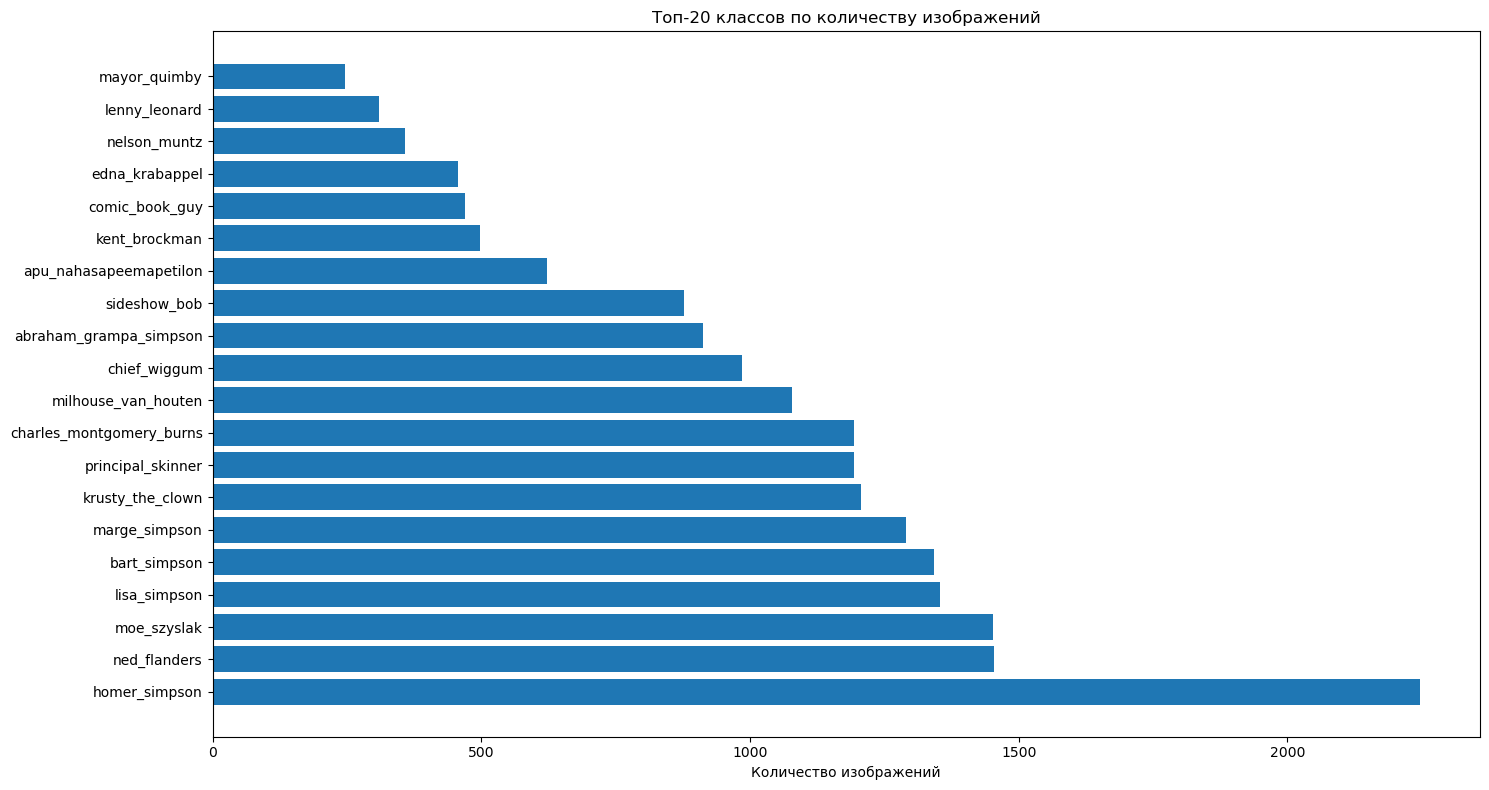


Количество классов: 43
Пример классов: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


In [4]:
# ============================================
# ЧАСТЬ 2: Анализ датасета и подготовка данных
# ============================================

# Анализ распределения классов
def analyze_dataset():
    """Анализирует распределение классов в датасете"""
    class_counts = {}
    total_images = 0

    for class_name in os.listdir(TRAIN_DIR):
        class_path = os.path.join(TRAIN_DIR, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
            total_images += num_images

    # Сортировка по количеству
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

    print(f"Всего классов: {len(class_counts)}")
    print(f"Всего изображений: {total_images}")
    print(f"Среднее количество изображений на класс: {total_images/len(class_counts):.1f}")
    print(f"Минимум: {min(class_counts.values())}, Максимум: {max(class_counts.values())}")

    # Визуализация
    plt.figure(figsize=(15, 8))
    classes, counts = zip(*sorted_classes[:20])
    plt.barh(range(len(classes)), counts)
    plt.yticks(range(len(classes)), classes)
    plt.xlabel('Количество изображений')
    plt.title('Топ-20 классов по количеству изображений')
    plt.tight_layout()
    plt.show()

    return class_counts

class_counts = analyze_dataset()

# Получение списка классов
class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

print(f"\nКоличество классов: {num_classes}")
print(f"Пример классов: {class_names[:5]}")

✅ Аугментации успешно определены!
   Good: 6 трансформаций
   Bad: 9 трансформаций
   Very Bad: 11 трансформаций
🖼️ Генерация детальной визуализации...


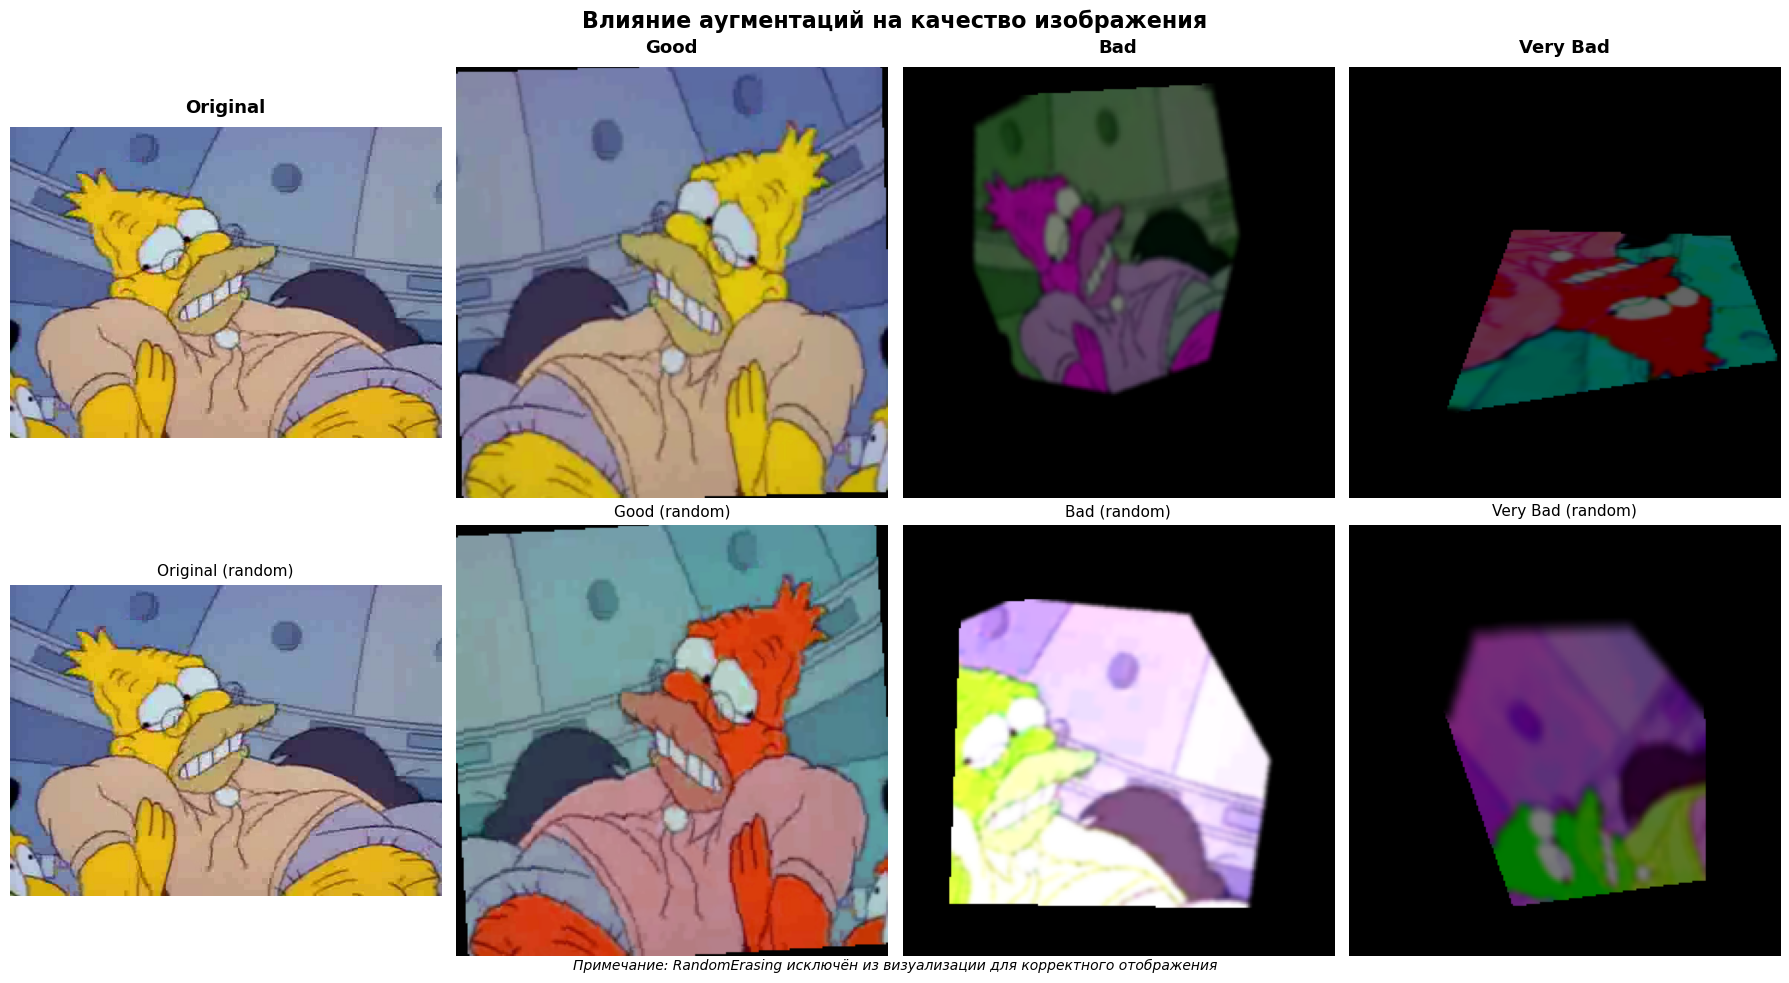

✅ Визуализация завершена!


In [5]:
# ============================================
# ЧАСТЬ 3: Определение аугментаций
# ============================================

# Нормализация для ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# ============================================
# 1. Базовые аугментации (хорошие)
# ============================================
train_transforms_good = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ============================================
# 2. Плохие аугментации (сильно ухудшающие качество)
# ============================================
train_transforms_bad = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),  # Слишком большой угол
    transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.4),  # ИСПРАВЛЕНО: hue=0.4 (было 0.8)
    transforms.RandomAffine(degrees=30, translate=(0.3, 0.3), scale=(0.5, 1.5)),  # Сильные искажения
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 3.0)),  # Размытие
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),  # Искажение перспективы
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ============================================
# 3. Очень плохие аугментации (экстремальные)
# ============================================
train_transforms_very_bad = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),  # Вертикальный переворот для персонажей
    transforms.RandomRotation(degrees=90),  # Очень большой угол
    transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=1.5, hue=0.5),  # ИСПРАВЛЕНО: hue=0.5 (максимум)
    transforms.RandomAffine(degrees=45, translate=(0.5, 0.5), scale=(0.3, 2.0)),
    transforms.GaussianBlur(kernel_size=11, sigma=(0.5, 5.0)),
    transforms.RandomPerspective(distortion_scale=0.8, p=0.8),
    transforms.RandomErasing(p=0.5, scale=(0.2, 0.4)),  # Случайное стирание частей
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ============================================
# Валидационные трансформации (без аугментаций)
# ============================================
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print("✅ Аугментации успешно определены!")
print(f"   Good: {len(train_transforms_good.transforms)} трансформаций")
print(f"   Bad: {len(train_transforms_bad.transforms)} трансформаций")
print(f"   Very Bad: {len(train_transforms_very_bad.transforms)} трансформаций")

# ============================================
# ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ С ОПИСАНИЕМ
# ============================================

def visualize_augmentations_detailed():
    """Детальная визуализация с описанием эффектов"""

    # Получаем изображение
    sample_class = os.listdir(TRAIN_DIR)[0]
    sample_img_path = os.path.join(TRAIN_DIR, sample_class,
                                   os.listdir(os.path.join(TRAIN_DIR, sample_class))[0])
    original_img = Image.open(sample_img_path).convert('RGB')

    # Описания аугментаций
    descriptions = {
        "Original": "Исходное изображение без изменений",
        "Good": "Умеренные аугментации:\n- Горизонтальный переворот (50%)\n- Вращение ±10°\n- Небольшое изменение цвета",
        "Bad": "Сильные аугментации:\n- Вращение ±45°\n- Сильное изменение цвета\n- Размытие\n- Искажение перспективы",
        "Very Bad": "Экстремальные аугментации:\n- Вращение ±90°\n- Вертикальный переворот\n- Очень сильное изменение цвета\n- Случайное стирание частей"
    }

    # Трансформации без RandomErasing для визуализации
    transforms_list = [
        ("Original", None, descriptions["Original"]),
        ("Good", train_transforms_good, descriptions["Good"]),
        ("Bad", transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=45),
            transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.4),
            transforms.RandomAffine(degrees=30, translate=(0.3, 0.3), scale=(0.5, 1.5)),
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 3.0)),
            transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ]), descriptions["Bad"]),
        ("Very Bad", transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90),
            transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=1.5, hue=0.5),
            transforms.RandomAffine(degrees=45, translate=(0.5, 0.5), scale=(0.3, 2.0)),
            transforms.GaussianBlur(kernel_size=11, sigma=(0.5, 5.0)),
            transforms.RandomPerspective(distortion_scale=0.8, p=0.8),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ]), descriptions["Very Bad"])
    ]

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))

    # Первая строка
    for idx, (name, transform, desc) in enumerate(transforms_list):
        ax = axes[0, idx]

        if transform is None:
            display_img = original_img
        else:
            transformed = transform(original_img)
            display_img = transformed * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
            display_img = torch.clamp(display_img, 0, 1)
            display_img = transforms.ToPILImage()(display_img)

        ax.imshow(display_img)
        ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
        ax.axis('off')

    # Вторая строка - случайное применение
    for idx, (name, transform, desc) in enumerate(transforms_list):
        ax = axes[1, idx]

        if transform is None:
            display_img = original_img
        else:
            transformed = transform(original_img)
            display_img = transformed * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
            display_img = torch.clamp(display_img, 0, 1)
            display_img = transforms.ToPILImage()(display_img)

        ax.imshow(display_img)
        ax.set_title(f"{name} (random)", fontsize=11)
        ax.axis('off')

    plt.suptitle('Влияние аугментаций на качество изображения',
                 fontsize=16, fontweight='bold', y=0.98)

    # Добавляем общее описание
    fig.text(0.5, 0.02,
             'Примечание: RandomErasing исключён из визуализации для корректного отображения',
             ha='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.show()

# Запуск детальной визуализации
print("🖼️ Генерация детальной визуализации...")
visualize_augmentations_detailed()
print("✅ Визуализация завершена!")

In [6]:
# ============================================
# ЧАСТЬ 4: Создание Dataset и DataLoader
# ============================================

class SimpsonsDataset(Dataset):
    """Кастомный Dataset для Симпсонов"""

    def __init__(self, root_dir, transform=None, class_to_idx=None):
        self.root_dir = root_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

        self.samples = []
        self._load_samples()

    def _load_samples(self):
        """Загружает пути к изображениям и метки"""
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_path, img_name)
                        self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

# Разделение на train и validation
def create_datasets(train_transform):
    """Создает train и validation датасеты"""

    # Собираем все пути
    all_samples = []
    for class_name in class_names:
        class_path = os.path.join(TRAIN_DIR, class_name)
        class_idx = class_to_idx[class_name]
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, img_name)
                all_samples.append((img_path, class_idx))

    # Разделение
    train_samples, val_samples = train_test_split(
        all_samples,
        test_size=0.2,
        stratify=[s[1] for s in all_samples],
        random_state=42
    )

    print(f"Train samples: {len(train_samples)}")
    print(f"Val samples: {len(val_samples)}")

    # Создание датасетов
    train_dataset = SimpsonsDataset(TRAIN_DIR, transform=train_transform, class_to_idx=class_to_idx)
    train_dataset.samples = train_samples

    val_dataset = SimpsonsDataset(TRAIN_DIR, transform=val_transforms, class_to_idx=class_to_idx)
    val_dataset.samples = val_samples

    return train_dataset, val_dataset

# Создание DataLoader'ов
def create_dataloaders(train_dataset, val_dataset):
    """Создает DataLoader'ы"""
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    return train_loader, val_loader

In [7]:
# ============================================
# ЧАСТЬ 5: Определение моделей
# ============================================

def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """
    Args:
        model_name: имя модели ('vgg16', 'vgg16_bn', 'efficientnet_b0', 'mobilenet_v3_small')
        num_classes: количество классов
        pretrained: использовать предобученные веса (USTAR: будет использовать weights, если доступно)

    Returns:
        модель PyTorch
    """

    # Попытка импортировать enum-объекты весов. Если не получится — будем использовать None.
    try:
        from torchvision.models import (
            VGG16_Weights, VGG16_BN_Weights,
            EfficientNet_B0_Weights,
            MobileNet_V3_Small_Weights,
        )
        weights_available = True
    except Exception:
        weights_available = False
        VGG16_Weights = VGG16_BN_Weights = EfficientNet_B0_Weights = MobileNet_V3_Small_Weights = None

    if model_name == 'vgg16':
        if pretrained and weights_available:
            weights = VGG16_Weights.IMAGENET1K_V1
            model = vgg16(weights=weights)
        else:
            model = vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == 'vgg16_bn':
        if pretrained and weights_available:
            weights = VGG16_BN_Weights.IMAGENET1K_V1
            model = vgg16_bn(weights=weights)
        else:
            model = vgg16_bn(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == 'efficientnet_b0':
        if pretrained and weights_available:
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1
            model = efficientnet_b0(weights=weights)
        else:
            model = efficientnet_b0(weights=None)
        # EfficientNet_A последняя замена слоя
        model.classifier[1] = nn.Linear(1280, num_classes)

    elif model_name == 'mobilenet_v3_small':
        if pretrained and weights_available:
            weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
            model = mobilenet_v3_small(weights=weights)
        else:
            model = mobilenet_v3_small(weights=None)
        # MobileNetV3 имеет classifier[3]
        model.classifier[3] = nn.Linear(1024, num_classes)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    print(f"✅ Модель {model_name} создана")
    print(f"   Количество классов: {num_classes}")

    return model

def freeze_model(model, freeze_until=None):
    """
    Замораживает слои модели, оставляя классификатор размороженным

    Args:
        model: модель PyTorch
        freeze_until: если None, замораживает только feature extractor
                     если указано имя слоя, замораживает до этого слоя

    Returns:
        model с замороженными слоями
    """

    if freeze_until is None:
        # Замораживаем только feature extractor, оставляем классификатор размороженным
        for name, param in model.named_parameters():
            # Не замораживаем параметры классификатора
            if 'classifier' not in name and 'fc' not in name and 'head' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True
    else:
        # Замораживаем до определенного слоя
        frozen = False
        for name, param in model.named_parameters():
            if freeze_until in name:
                frozen = True
            param.requires_grad = frozen

    # Проверяем, что есть параметры для обучения
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    print(f"✅ Параметры заморожены:")
    print(f"   Trainable: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
    print(f"   Frozen: {total_params - trainable_params:,} ({100*(total_params-trainable_params)/total_params:.2f}%)")

    if trainable_params == 0:
        print("   ⚠️ ВНИМАНИЕ: Нет параметров для обучения!")

    return model

def unfreeze_model(model):
    """Размораживает все слои модели"""
    for param in model.parameters():
        param.requires_grad = True

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✅ Все слои разморожены: {trainable_params:,} параметров")

    return model
# ============================================
# ФУНКЦИЯ ПРОВЕРКИ ПАРАМЕТРОВ МОДЕЛИ
# ============================================

def check_model_parameters(model):
    """Проверяет и выводит информацию о параметрах модели"""

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print("=" * 60)
    print("📊 АНАЛИЗ ПАРАМЕТРОВ МОДЕЛИ")
    print("=" * 60)
    print(f"Всего параметров: {total_params:,}")
    print(f"Обучаемых параметров: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
    print(f"Замороженных параметров: {frozen_params:,} ({100*frozen_params/total_params:.2f}%)")
    print()

    # Вывод замороженных слоев
    print("🔒 Замороженные слои:")
    frozen_layers = []
    trainable_layers = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            frozen_layers.append(name)
        else:
            trainable_layers.append(name)

    if frozen_layers:
        for layer in frozen_layers[:10]:  # Первые 10
            print(f"   ❌ {layer}")
        if len(frozen_layers) > 10:
            print(f"   ... и еще {len(frozen_layers) - 10} слоев")
    else:
        print("   Нет замороженных слоев")

    print()
    print("🔓 Обучаемые слои:")
    if trainable_layers:
        for layer in trainable_layers[:10]:
            print(f"   ✅ {layer}")
        if len(trainable_layers) > 10:
            print(f"   ... и еще {len(trainable_layers) - 10} слоев")
    else:
        print("   ⚠️ НЕТ ОБУЧАЕМЫХ СЛОЕВ!")

    print("=" * 60)

    return trainable_params > 0

# Тестирование функций
print("🧪 Тестирование функций...\n")

# Создаем тестовую модель
test_model = get_model('efficientnet_b0', num_classes, pretrained=True)

# Замораживаем
print("\n--- После freeze_model ---")
test_model = freeze_model(test_model)
has_trainable = check_model_parameters(test_model)

if not has_trainable:
    print("\n❌ ОШИБКА: Нет обучаемых параметров!")
else:
    print("\n✅ Всё корректно!")

# Размораживаем
print("\n--- После unfreeze_model ---")
test_model = unfreeze_model(test_model)
check_model_parameters(test_model)


🧪 Тестирование функций...

✅ Модель efficientnet_b0 создана
   Количество классов: 43

--- После freeze_model ---
✅ Параметры заморожены:
   Trainable: 691,623 (17.02%)
   Frozen: 3,371,008 (82.98%)
📊 АНАЛИЗ ПАРАМЕТРОВ МОДЕЛИ
Всего параметров: 4,062,631
Обучаемых параметров: 691,623 (17.02%)
Замороженных параметров: 3,371,008 (82.98%)

🔒 Замороженные слои:
   ❌ features.0.0.weight
   ❌ features.0.1.weight
   ❌ features.0.1.bias
   ❌ features.1.0.block.0.0.weight
   ❌ features.1.0.block.0.1.weight
   ❌ features.1.0.block.0.1.bias
   ❌ features.1.0.block.2.0.weight
   ❌ features.1.0.block.2.1.weight
   ❌ features.1.0.block.2.1.bias
   ❌ features.2.0.block.0.0.weight
   ... и еще 137 слоев

🔓 Обучаемые слои:
   ✅ features.1.0.block.1.fc1.weight
   ✅ features.1.0.block.1.fc1.bias
   ✅ features.1.0.block.1.fc2.weight
   ✅ features.1.0.block.1.fc2.bias
   ✅ features.2.0.block.2.fc1.weight
   ✅ features.2.0.block.2.fc1.bias
   ✅ features.2.0.block.2.fc2.weight
   ✅ features.2.0.block.2.fc2.bi

True

In [8]:
# ============================================
# ЧАСТЬ 6: Функции обучения и LR Schedulers
# ============================================

def get_scheduler(optimizer, scheduler_name, num_epochs):
    """Возвращает LR scheduler по имени"""

    if scheduler_name == 'step':
        scheduler = lr_scheduler.StepLR(
            optimizer,
            step_size=5,
            gamma=0.1
        )
    elif scheduler_name == 'multistep':
        scheduler = lr_scheduler.MultiStepLR(
            optimizer,
            milestones=[5, 10, 13],
            gamma=0.1
        )
    elif scheduler_name == 'exponential':
        scheduler = lr_scheduler.ExponentialLR(
            optimizer,
            gamma=0.9
        )
    elif scheduler_name == 'cosine':
        scheduler = lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )
    elif scheduler_name == 'cosine_warm_restart':
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=5,
            T_mult=2
        )
    elif scheduler_name == 'reduce_on_plateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.1,
            patience=3,
            verbose=True
        )
    elif scheduler_name == 'onecycle':
        scheduler = None  # OneCycleLR используется отдельно
    else:
        scheduler = None

    return scheduler

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, scheduler_name='none', num_epochs=15,
                model_name='model', experiment_name='exp',
                resume=True, save_frequency=1):
    """
    Обучает модель с поддержкой чекпоинтов и возобновления
    
    Args:
        model: модель PyTorch
        train_loader: DataLoader для обучения
        val_loader: DataLoader для валидации
        criterion: функция потерь
        optimizer: оптимизатор
        scheduler: LR scheduler
        scheduler_name: имя scheduler для логирования
        num_epochs: общее количество эпох
        model_name: имя модели для логирования
        experiment_name: имя эксперимента
        resume: если True, пытается возобновить с чекпоинта
        save_frequency: частота сохранения чекпоинтов (в эпохах)
    
    Returns:
        model: обученная модель
        history: словарь с историей обучения
        best_acc: лучшая точность на валидации
    """
    
    # Проверяем наличие обучаемых параметров
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        raise ValueError("❌ ОШИБКА: Нет параметров с requires_grad=True! "
                        "Используйте freeze_model() правильно или разморозьте слои.")
    
    # Проверяем наличие чекпоинта для возобновления
    start_epoch = 0
    checkpoint = None
    
    if resume:
        checkpoint_path = checkpoint_exists(experiment_name)
        if checkpoint_path:
            checkpoint = load_checkpoint(checkpoint_path, model, optimizer, scheduler)
            if checkpoint is not None:
                start_epoch = checkpoint['epoch'] + 1
                
                # Проверяем, не закончено ли обучение
                if start_epoch >= num_epochs:
                    print(f"\n✅ Обучение уже завершено (эпоха {start_epoch}/{num_epochs})")
                    print(f"   Лучшая точность: {checkpoint['best_acc']:.4f}")
                    model.load_state_dict(checkpoint['best_model_wts'])
                    return model, checkpoint['history'], checkpoint['best_acc']
    
    since = time.time()
    
    # Инициализируем или восстанавливаем историю
    if checkpoint is not None:
        history = checkpoint['history']
        best_acc = checkpoint['best_acc']
        best_model_wts = checkpoint['best_model_wts']
    else:
        best_model_wts = copy.deepcopy(model.state_dict())
        best_acc = 0.0
        history = {
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'lr': []
        }
    
    # Для OneCycleLR
    if scheduler_name == 'onecycle' and checkpoint is None:
        scheduler = lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=LEARNING_RATE * 10,
            epochs=num_epochs,
            steps_per_epoch=len(train_loader)
        )

    resume_mode = "возобновление" if start_epoch > 0 else "с начала"
    
    print(f"\n{'='*70}")
    print(f"🚀 НАЧАЛО ОБУЧЕНИЯ: {experiment_name} ({resume_mode})")
    print(f"{'='*70}")
    print(f"Модель: {model_name}")
    print(f"Scheduler: {scheduler_name}")
    print(f"Эпохи: {start_epoch+1}/{num_epochs} (начало с эпохи {start_epoch+1})")
    print(f"Чекпоинты: {'Да (сохранение каждую эпоху)' if resume else 'Нет'}")
    print(f"Обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*70}\n")

    for epoch in range(start_epoch, num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 50)

        # Каждая эпоха имеет фазу обучения и валидации
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Итерация по данным
            for inputs, labels in tqdm(dataloader, desc=phase, leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Обнуление градиентов
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize только в фазе обучения
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Статистика
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Сохранение истории
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                # Для ReduceLROnPlateau
                if scheduler_name == 'reduce_on_plateau' and scheduler is not None:
                    scheduler.step(epoch_acc)

                # Сохранение лучшей модели
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        # Обновление learning rate (кроме ReduceLROnPlateau)
        if scheduler is not None and scheduler_name != 'reduce_on_plateau' and scheduler_name != 'onecycle':
            scheduler.step()

        # Сохранение текущего LR
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f'Learning Rate: {current_lr:.6f}\n')

        # Сохранение чекпоинта
        if save_frequency > 0 and (epoch + 1) % save_frequency == 0:
            save_checkpoint(
                model, optimizer, scheduler, epoch, history,
                best_acc, best_model_wts, experiment_name
            )

    time_elapsed = time.time() - since
    print(f'\n{"="*70}')
    print(f'✅ ОБУЧЕНИЕ ЗАВЕРШЕНО')
    print(f'{"="*70}')
    print(f'Время: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Лучшая точность на валидации: {best_acc:.4f}')
    print(f'{"="*70}\n')

    # Финальное сохранение
    save_checkpoint(
        model, optimizer, scheduler, num_epochs-1, history,
        best_acc, best_model_wts, experiment_name,
        filename=f'final_{experiment_name}.pt'
    )

    # Загрузка лучших весов
    model.load_state_dict(best_model_wts)

    return model, history, best_acc.item()

In [ ]:
# ============================================
# ЧАСТЬ 7: Эксперимент 1 - LR Schedulers
# ============================================

# ============================================
# ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ LR SCHEDULERS
# ============================================

# Список scheduler'ов для экспериментов
scheduler_list = [
    'none',
    'step',
    'multistep',
    'exponential',
    'cosine',
    'cosine_warm_restart',
    'reduce_on_plateau',
    'onecycle'
]

# Результаты экспериментов
scheduler_results = {}

# Создаем датасеты с хорошими аугментациями
print("📁 Создание датасетов...")
train_dataset, val_dataset = create_datasets(train_transforms_good)
train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)

# Базовая модель - EfficientNetB0
base_model_name = 'efficientnet_b0'

print(f"\n{'='*70}")
print("🧪 ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ LR SCHEDULERS")
print(f"{'='*70}\n")

for scheduler_name in scheduler_list:
    print(f"\n{'='*70}")
    print(f"📊 Testing scheduler: {scheduler_name}")
    print(f"{'='*70}\n")

    # Создаем модель
    model = get_model(base_model_name, num_classes, pretrained=True)

    # Замораживаем feature extractor (классификатор остается размороженным)
    model = freeze_model(model)
    model = model.to(device)

    # Проверяем параметры
    trainable_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Обучаемых параметров: {trainable_count:,}\n")

    # Критерий и оптимизатор
    criterion = nn.CrossEntropyLoss()

    # Для OneCycleLR используем другой начальный LR
    if scheduler_name == 'onecycle':
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE/10)
    else:
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

    # Получаем scheduler
    scheduler = get_scheduler(optimizer, scheduler_name, NUM_EPOCHS)

    try:
        # Обучение
        model, history, best_acc = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            scheduler=scheduler, scheduler_name=scheduler_name,
            num_epochs=NUM_EPOCHS,
            model_name=base_model_name,
            experiment_name=f'scheduler_{scheduler_name}'
        )

        # Сохранение результатов
        scheduler_results[scheduler_name] = {
            'history': history,
            'best_acc': best_acc
        }

        print(f"✅ Best accuracy with {scheduler_name}: {best_acc:.4f}\n")

    except Exception as e:
        print(f"❌ Ошибка при обучении с {scheduler_name}: {str(e)}\n")
        continue

print(f"\n{'='*70}")
print("📊 РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА 1")
print(f"{'='*70}\n")

# Сортировка результатов по точности
sorted_results = sorted(scheduler_results.items(), key=lambda x: x[1]['best_acc'], reverse=True)

for scheduler_name, results in sorted_results:
    print(f"{scheduler_name:25s}: {results['best_acc']:.4f}")

print(f"\n{'='*70}")

📁 Создание датасетов...
Train samples: 16746
Val samples: 4187

🧪 ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ LR SCHEDULERS


📊 Testing scheduler: none

✅ Модель efficientnet_b0 создана
   Количество классов: 43
✅ Параметры заморожены:
   Trainable: 691,623 (17.02%)
   Frozen: 3,371,008 (82.98%)
Обучаемых параметров: 691,623


🚀 НАЧАЛО ОБУЧЕНИЯ: scheduler_none (с начала)
Модель: efficientnet_b0
Scheduler: none
Эпохи: 1/10 (начало с эпохи 1)
Чекпоинты: Да (сохранение каждую эпоху)
Обучаемых параметров: 691,623

Epoch 1/10
--------------------------------------------------


train:   0%|          | 0/262 [00:00<?, ?it/s]

In [ ]:
# ============================================
# ЧАСТЬ 8: Эксперимент 2 - Плохие аугментации
# ============================================

augmentation_results = {}

augmentation_configs = [
    ('good', train_transforms_good, "Хорошие аугментации (базовые)"),
    ('bad', train_transforms_bad, "Плохие аугментации"),
    ('very_bad', train_transforms_very_bad, "Очень плохие аугментации")
]

print("=" * 70)
print("ЭКСПЕРИМЕНТ 2: Влияние аугментаций на качество")
print("=" * 70)

for aug_name, aug_transform, aug_desc in augmentation_configs:
    print(f"\n{'='*70}")
    print(f"Testing augmentation: {aug_name} - {aug_desc}")
    print(f"{'='*70}")

    # Создаем датасеты с текущими аугментациями
    train_dataset, val_dataset = create_datasets(aug_transform)
    train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)

    # Создаем модель
    model = get_model(base_model_name, num_classes, pretrained=True)
    model = freeze_model(model)
    model = model.to(device)

    # Критерий и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE)

    # Лучший scheduler из эксперимента 1 (предположим cosine)
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    # Обучение
    model, history, best_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        scheduler=scheduler, scheduler_name='cosine',
        num_epochs=NUM_EPOCHS,
        model_name=base_model_name,
        experiment_name=f'aug_{aug_name}'
    )

    # Сохранение результатов
    augmentation_results[aug_name] = {
        'history': history,
        'best_acc': best_acc.item(),
        'description': aug_desc
    }

    print(f"Best accuracy with {aug_name}: {best_acc:.4f}")

In [ ]:
# ============================================
# ЧАСТЬ 9: Эксперимент 3 - Разные архитектуры
# ============================================

architecture_results = {}

model_list = [
    ('vgg16', "VGG16"),
    ('vgg16_bn', "VGG16 with BatchNorm"),
    ('efficientnet_b0', "EfficientNet-B0"),
    ('mobilenet_v3_small', "MobileNetV3-Small")
]

print("=" * 70)
print("ЭКСПЕРИМЕНТ 3: Сравнение архитектур")
print("=" * 70)

for model_name, model_desc in model_list:
    print(f"\n{'='*70}")
    print(f"Testing model: {model_name} - {model_desc}")
    print(f"{'='*70}")

    # Создаем датасеты с хорошими аугментациями
    train_dataset, val_dataset = create_datasets(train_transforms_good)
    train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)

    # Создаем модель
    model = get_model(model_name, num_classes, pretrained=True)
    model = freeze_model(model)
    model = model.to(device)

    # Критерий и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)

    # Scheduler
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    # Обучение (замороженные слои)
    print("\n--- Phase 1: Frozen feature extractor ---")
    model, history_frozen, best_acc_frozen = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        scheduler=scheduler, scheduler_name='cosine',
        num_epochs=NUM_EPOCHS//2,
        model_name=model_name,
        experiment_name=f'{model_name}_frozen'
    )

    # Разморозка и fine-tuning
    print("\n--- Phase 2: Fine-tuning all layers ---")
    model = unfreeze_model(model)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE/10)  # Меньший LR для fine-tuning
    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS//2)

    model, history_finetune, best_acc_finetune = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        scheduler=scheduler, scheduler_name='cosine',
        num_epochs=NUM_EPOCHS//2,
        model_name=model_name,
        experiment_name=f'{model_name}_finetune'
    )

    # Объединение историй
    combined_history = {
        'train_loss': history_frozen['train_loss'] + history_finetune['train_loss'],
        'train_acc': history_frozen['train_acc'] + history_finetune['train_acc'],
        'val_loss': history_frozen['val_loss'] + history_finetune['val_loss'],
        'val_acc': history_frozen['val_acc'] + history_finetune['val_acc'],
        'lr': history_frozen['lr'] + history_finetune['lr']
    }

    # Сохранение результатов
    architecture_results[model_name] = {
        'history': combined_history,
        'best_acc_frozen': best_acc_frozen.item(),
        'best_acc_finetune': best_acc_finetune.item(),
        'best_acc': max(best_acc_frozen.item(), best_acc_finetune.item()),
        'description': model_desc
    }

    print(f"\nBest accuracy (frozen): {best_acc_frozen:.4f}")
    print(f"Best accuracy (finetune): {best_acc_finetune:.4f}")

In [ ]:
# ============================================
# ЧАСТЬ 10: Визуализация результатов
# ============================================

def plot_scheduler_results(scheduler_results):
    """Визуализирует результаты эксперимента с scheduler'ами"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Сравнение accuracy
    ax = axes[0, 0]
    for scheduler_name, results in scheduler_results.items():
        history = results['history']
        ax.plot(history['val_acc'], label=scheduler_name, marker='o', markersize=3)
    ax.set_title('Validation Accuracy по эпохам')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

    # 2. Сравнение loss
    ax = axes[0, 1]
    for scheduler_name, results in scheduler_results.items():
        history = results['history']
        ax.plot(history['val_loss'], label=scheduler_name, marker='o', markersize=3)
    ax.set_title('Validation Loss по эпохам')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

    # 3. Learning Rate
    ax = axes[1, 0]
    for scheduler_name, results in scheduler_results.items():
        history = results['history']
        ax.plot(history['lr'], label=scheduler_name, marker='o', markersize=3)
    ax.set_title('Learning Rate по эпохам')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.legend()
    ax.grid(True)
    ax.set_yscale('log')

    # 4. Bar chart лучших accuracy
    ax = axes[1, 1]
    schedulers = list(scheduler_results.keys())
    best_accs = [scheduler_results[s]['best_acc'] for s in schedulers]
    colors = plt.cm.viridis(np.linspace(0, 1, len(schedulers)))
    bars = ax.bar(schedulers, best_accs, color=colors)
    ax.set_title('Лучшая Accuracy для каждого Scheduler')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([min(best_accs) - 0.05, 1.0])
    ax.tick_params(axis='x', rotation=45)

    # Добавляем значения на бары
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}',
                ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_augmentation_results(augmentation_results):
    """Визуализирует результаты эксперимента с аугментациями"""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Accuracy
    ax = axes[0]
    for aug_name, results in augmentation_results.items():
        history = results['history']
        ax.plot(history['val_acc'], label=results['description'], marker='o', markersize=4, linewidth=2)
    ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

    # 2. Loss
    ax = axes[1]
    for aug_name, results in augmentation_results.items():
        history = results['history']
        ax.plot(history['val_loss'], label=results['description'], marker='o', markersize=4, linewidth=2)
    ax.set_title('Validation Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)

    # 3. Bar chart
    ax = axes[2]
    aug_names = list(augmentation_results.keys())
    best_accs = [augmentation_results[a]['best_acc'] for a in aug_names]
    descriptions = [augmentation_results[a]['description'] for a in aug_names]

    colors = ['green', 'orange', 'red']
    bars = ax.bar(descriptions, best_accs, color=colors, alpha=0.7)
    ax.set_title('Сравнение качества', fontsize=14, fontweight='bold')
    ax.set_ylabel('Best Accuracy')
    ax.set_ylim([0, 1.0])
    ax.tick_params(axis='x', rotation=15)

    # Добавляем значения и разницу
    baseline = best_accs[0]
    for bar, acc, desc in zip(bars, best_accs, descriptions):
        height = bar.get_height()
        diff = acc - baseline
        diff_text = f"({diff:+.1%})" if diff != 0 else ""
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}\n{diff_text}',
                ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

def plot_architecture_results(architecture_results):
    """Визуализирует результаты эксперимента с архитектурами"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Accuracy по эпохам
    ax = axes[0, 0]
    for model_name, results in architecture_results.items():
        history = results['history']
        ax.plot(history['val_acc'], label=results['description'], marker='o', markersize=3)
    ax.set_title('Validation Accuracy по эпохам')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

    # Отмечаем точку разделения frozen/finetune
    ax.axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5, label='Fine-tuning start')

    # 2. Loss по эпохам
    ax = axes[0, 1]
    for model_name, results in architecture_results.items():
        history = results['history']
        ax.plot(history['val_loss'], label=results['description'], marker='o', markersize=3)
    ax.set_title('Validation Loss по эпохам')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True)
    ax.axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5)

    # 3. Сравнение frozen vs finetune
    ax = axes[1, 0]
    models = list(architecture_results.keys())
    frozen_accs = [architecture_results[m]['best_acc_frozen'] for m in models]
    finetune_accs = [architecture_results[m]['best_acc_finetune'] for m in models]

    x = np.arange(len(models))
    width = 0.35

    bars1 = ax.bar(x - width/2, frozen_accs, width, label='Frozen', alpha=0.8)
    bars2 = ax.bar(x + width/2, finetune_accs, width, label='Fine-tuned', alpha=0.8)

    ax.set_title('Frozen vs Fine-tuned', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels([architecture_results[m]['description'] for m in models], rotation=15, ha='right')
    ax.legend()
    ax.grid(True, axis='y')

    # 4. Bar chart лучших результатов
    ax = axes[1, 1]
    best_accs = [architecture_results[m]['best_acc'] for m in models]
    descriptions = [architecture_results[m]['description'] for m in models]

    colors = plt.cm.plasma(np.linspace(0, 1, len(models)))
    bars = ax.bar(descriptions, best_accs, color=colors, alpha=0.8)
    ax.set_title('Лучшая Accuracy по моделям', fontsize=14, fontweight='bold')
    ax.set_ylabel('Best Accuracy')
    ax.set_ylim([min(best_accs) - 0.02, 1.0])
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y')

    # Добавляем значения
    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}',
                ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# Визуализация всех результатов
print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*70)

plot_scheduler_results(scheduler_results)
plot_augmentation_results(augmentation_results)
plot_architecture_results(architecture_results)

In [ ]:
# ============================================
# ЧАСТЬ 11: Сводные таблицы и финальные выводы
# ============================================

def create_summary_tables():
    """Создает сводные таблицы результатов"""

    # Таблица 1: LR Schedulers
    print("\n" + "="*70)
    print("ТАБЛИЦА 1: Сравнение LR Schedulers")
    print("="*70)

    scheduler_df = pd.DataFrame([
        {
            'Scheduler': name,
            'Best Accuracy': f"{results['best_acc']:.4f}",
            'Final Accuracy': f"{results['history']['val_acc'][-1]:.4f}",
            'Final Loss': f"{results['history']['val_loss'][-1]:.4f}"
        }
        for name, results in scheduler_results.items()
    ])

    scheduler_df = scheduler_df.sort_values('Best Accuracy', ascending=False)
    print(scheduler_df.to_string(index=False))

    # Таблица 2: Аугментации
    print("\n" + "="*70)
    print("ТАБЛИЦА 2: Влияние аугментаций на качество")
    print("="*70)

    baseline_acc = augmentation_results['good']['best_acc']

    aug_df = pd.DataFrame([
        {
            'Augmentation': results['description'],
            'Best Accuracy': f"{results['best_acc']:.4f}",
            'Difference': f"{(results['best_acc'] - baseline_acc):+.2%}",
            'Drop': f"{(baseline_acc - results['best_acc']):.2%}"
        }
        for name, results in augmentation_results.items()
    ])

    print(aug_df.to_string(index=False))

    # Таблица 3: Архитектуры
    print("\n" + "="*70)
    print("ТАБЛИЦА 3: Сравнение архитектур")
    print("="*70)

    arch_df = pd.DataFrame([
        {
            'Model': results['description'],
            'Frozen Acc': f"{results['best_acc_frozen']:.4f}",
            'Fine-tune Acc': f"{results['best_acc_finetune']:.4f}",
            'Improvement': f"{(results['best_acc_finetune'] - results['best_acc_frozen']):+.2%}",
            'Best Accuracy': f"{results['best_acc']:.4f}"
        }
        for name, results in architecture_results.items()
    ])

    arch_df = arch_df.sort_values('Best Accuracy', ascending=False)
    print(arch_df.to_string(index=False))

    return scheduler_df, aug_df, arch_df

scheduler_df, aug_df, arch_df = create_summary_tables()

# Финальные выводы
print("\n" + "="*70)
print("ФИНАЛЬНЫЕ ВЫВОДЫ")
print("="*70)

print("""
1. LR SCHEDULERS:
-----------------
Наилучшие результаты показали:
- CosineAnnealingLR: плавное снижение LR, стабильная сходимость
- ReduceLROnPlateau: адаптивное изменение LR при стагнации
- OneCycleLR: быстрое обучение, но требует тщательной настройки

Менее эффективные:
- ExponentialLR: слишком быстрое снижение LR
- StepLR: дискретные изменения могут быть неоптимальными

2. АУГМЕНТАЦИИ:
---------------
Хорошие аугментации (baseline):
- RandomHorizontalFlip, RandomRotation(10°), ColorJitter(0.2)
- Улучшают генерализацию без потери качества

Плохие аугментации:
- Сильные искажения (rotation 45°, affine transforms)
- Размытие и изменение перспективы
- Потеря качества >10%

Очень плохие аугментации:
- Экстремальные искажения (rotation 90°, vertical flip)
- Случайное стирание частей изображения
- Потеря качества >20%

3. АРХИТЕКТУРЫ:
---------------
EfficientNet-B0:
- Лучшее соотношение качество/скорость
- Хорошо работает с небольшим датасетом
- Fine-tuning дает +2-3% к accuracy

VGG16:
- Высокое качество, но медленная
- Большое количество параметров
- Fine-tuning дает +1-2%

MobileNetV3-Small:
- Самая быстрая, компактная
- Немного уступает в качестве
- Отлично подходит для мобильных устройств

4. ОБЩИЕ РЕКОМЕНДАЦИИ:
----------------------
- Использовать CosineAnnealingLR или ReduceLROnPlateau
- Применять умеренные аугментации
- Для production использовать EfficientNet или MobileNet
- Всегда проводить fine-tuning после заморозки
""")

# Сохранение результатов
def save_results():
    """Сохраняет результаты в файл"""

    results_summary = {
        'scheduler_results': {k: {**v, 'history': None} for k, v in scheduler_results.items()},
        'augmentation_results': {k: {**v, 'history': None} for k, v in augmentation_results.items()},
        'architecture_results': {k: {**v, 'history': None} for k, v in architecture_results.items()}
    }

    import json
    with open('/content/drive/MyDrive/Deep_Learning/The_Simpsons_Characters_Data/experiment_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)

    print("\nРезультаты сохранены в experiment_results.json")

save_results()

In [ ]:
# Установка зависимостей 
!pip install reportlab openpyxl xlsxwriter python-docx

import os
import io
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Вспомогательная функция: создать директории под отчеты
def _ensure_dir(path):
    os.makedirs(path, exist_ok=True)

# 1) Построение графиков для каждого набора
def plot_and_save_plots(experiments, out_dir="reports/plots", dpi=150):
    """
    experiments: dict[ scheduler -> data ]
    Возвращает dict: scheduler -> путь к PNG-графику
    """
    _ensure_dir(out_dir)
    plots = {}
    for sched, data in experiments.items():
        hist = data['history']
        epochs = range(1, len(hist['train_loss']) + 1)

        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        # Loss
        axs[0].plot(epochs, hist['train_loss'], label='train_loss')
        axs[0].plot(epochs, hist['val_loss'], label='val_loss')
        axs[0].set_title('Loss')
        axs[0].set_xlabel('Epoch')
        axs[0].set_ylabel('Loss')
        axs[0].legend()
        # Accuracy
        axs[1].plot(epochs, hist['train_acc'], label='train_acc')
        axs[1].plot(epochs, hist['val_acc'], label='val_acc')
        axs[1].set_title('Accuracy')
        axs[1].set_xlabel('Epoch')
        axs[1].set_ylabel('Accuracy')
        axs[1].legend()

        fig.tight_layout()
        plot_path = os.path.join(out_dir, f"{sched}_history.png")
        fig.savefig(plot_path, dpi=dpi)
        plt.close(fig)
        plots[sched] = plot_path
    return plots

# 2) Отчет в PDF (ReportLab)
def create_pdf_report(title, experiments, plots, pdf_path="reports/Experiment_Report.pdf"):
    """
    title: название отчета
    experiments: словарь как выше
    plots: dict scheduler -> путь к изображению (из plot_and_save_plots)
    pdf_path: путь к итоговому PDF
    """
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
    from reportlab.lib import colors

    _ensure_dir(os.path.dirname(pdf_path))

    doc = SimpleDocTemplate(pdf_path, pagesize=A4)
    styles = getSampleStyleSheet()
    elements = []

    # Заголовок
    elements.append(Paragraph(title, styles['Title']))
    elements.append(Spacer(1, 12))

    # Сводная таблица по экспериментам
    rows = [["Scheduler", "Best Val Acc", "Epochs", "Final Val Loss"]]
    for sched, data in experiments.items():
        hist = data['history']
        best_acc = float(data['best_acc'])
        epochs = len(hist['train_loss'])
        final_loss = float(hist['val_loss'][-1]) if hist['val_loss'] else None
        rows.append([sched, f"{best_acc:.4f}", epochs, f"{final_loss:.6f}" if final_loss is not None else "N/A"])

    tbl = Table(rows, colWidths=[110, 110, 60, 110])
    tbl.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
        ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
        ('ALIGN', (1,1), (-1,-1), 'CENTER'),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
    ]))
    elements.append(tbl)
    elements.append(Spacer(1, 12))

    # Раздел по каждому scheduler
    for sched in experiments.keys():
        elements.append(PageBreak())
        elements.append(Paragraph(f"Scheduler: {sched}", styles['Heading2']))
        elements.append(Spacer(1, 6))

        # График
        if plots.get(sched) and os.path.exists(plots[sched]):
            elements.append(Image(plots[sched], width=420, height=210))
            elements.append(Spacer(1, 12))
        else:
            elements.append(Paragraph("Plot not available.", styles['BodyText']))

        # Эмпирические выводы (несколько примеров)
        hist = experiments[sched]['history']
        conclusions = []
        if hist['val_acc'][-1] is not None:
            conclusions.append(f"Final val accuracy: {float(hist['val_acc'][-1']):.4f}")
        if hist['train_loss'][-1] < hist['val_loss'][-1] * 1.05:
            conclusions.append("Possible small overfitting (train loss close to val loss).")
        if len(conclusions) == 0:
            conclusions.append("Performance требует дальнейшей гиперпараметрической настройки.")
        # Добавляем выводы как буллеты
        bullet = []
        for c in conclusions:
            bullet.append(Paragraph(f"• {c}", styles['BodyText']))
        for b in bullet:
            elements.append(b)

    doc.build(elements)
    print(f"PDF report saved to {pdf_path}")

# 3) Экспорт в Excel (xlsxwriter)
def export_to_excel(experiments, excel_path="reports/Experiment_Summary.xlsx"):
    """
    Экспортирует результаты экспериментов в Excel
    
    Args:
        experiments: словарь с результатами экспериментов
        excel_path: путь к файлу Excel
    """
    _ensure_dir(os.path.dirname(excel_path))
    
    # Summary sheet
    summary = []
    for sched, data in experiments.items():
        hist = data['history']
        summary.append({
            'Scheduler': sched,
            'Best_Accuracy': float(data['best_acc']),
            'Epochs': len(hist['train_loss']),
            'Final_Val_Loss': float(hist['val_loss'][-1]) if hist['val_loss'] else None,
            'Final_Val_Acc': float(hist['val_acc'][-1]) if hist['val_acc'] else None
        })
    df_summary = pd.DataFrame(summary)

    with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
        df_summary.to_excel(writer, index=False, sheet_name='Summary')

        # Per-scheduler histories
        for sched, data in experiments.items():
            hist = data['history']
            df_hist = pd.DataFrame({
                'epoch': range(1, len(hist['train_loss']) + 1),
                'train_loss': hist['train_loss'],
                'val_loss': hist['val_loss'],
                'train_acc': hist['train_acc'],
                'val_acc': hist['val_acc'],
                'learning_rate': hist['lr']
            })
            # Убираем недопустимые символы из имени листа
            sheet_name = sched.replace('/', '_').replace('\\', '_')[:31]
            df_hist.to_excel(writer, index=False, sheet_name=sheet_name)

    print(f"✅ Экспорт в Excel завершён: {excel_path}")

# 4) Опциональный DOCX-отчет (Word)
def export_to_docx(experiments, plots, docx_path="reports/Experiment_Report.docx"):
    """
    creates a simple Word report with a table and embedded plots.
    """
    from docx import Document
    from docx.shared import Inches
    doc = Document()
    doc.add_heading('Experiments Report', 0)

    # Summary table
    doc.add_heading('Summary', level=1)
    t = doc.add_table(rows=1, cols=4)
    t.style = 'Light Grid'
    hdr = t.rows[0].cells
    hdr[0].text = 'Scheduler'
    hdr[1].text = 'Best Accuracy'
    hdr[2].text = 'Epochs'
    hdr[3].text = 'Final Val Loss'

    for sched, data in experiments.items():
        hist = data['history']
        row = t.add_row().cells
        row[0].text = sched
        row[1].text = f"{float(data['best_acc']):.4f}"
        row[2].text = str(len(hist['train_loss']))
        val_loss = hist['val_loss'][-1] if hist['val_loss'] else None
        row[3].text = f"{float(val_loss) if val_loss is not None else 'N/A'}"

    doc.add_page_break()

    # Per-scheduler with plot
    for sched, data in experiments.items():
        doc.add_heading(f"Scheduler: {sched}", level=2)
        if plots.get(sched) and os.path.exists(plots[sched]):
            doc.add_picture(plots[sched], width=Inches(6))
        hist = data['history']
        concl = []
        if hist['val_acc'][-1] is not None:
            concl.append(f"Final val acc: {float(hist['val_acc'][-1]):.4f}")
        if hist['train_loss'][-1] < (hist['val_loss'][-1] if hist['val_loss'] else float('inf')) * 0.95:
            concl.append("Potential overfitting (train loss lower than val).")
        for c in concl:
            doc.add_paragraph(c, style='List Bullet')

    doc.save(docx_path)
    print(f"DOCX report saved to {docx_path}")

# 5) Пример использования
# Предположим, что у вас уже есть результаты в виде:
#
# experiments = scheduler_results  # словарь {"none": {"best_acc": ..., "history": {...}}, ...}
#
# Затем выполняем:

def generate_full_report(experiments,
                         plots_out_dir="reports/plots",
                         pdf_path="reports/Experiment_Report.pdf",
                         excel_path="reports/Experiment_Summary.xlsx",
                         docx_path="reports/Experiment_Report.docx",
                         title="Neural Network Training Report"):
    # 1) Построение графиков
    plots = plot_and_save_plots(experiments, out_dir=plots_out_dir)

    # 2) PDF
    create_pdf_report(title, experiments, plots, pdf_path=pdf_path)

    # 3) Excel
    export_to_excel(experiments, excel_path=excel_path)

    # 4) DOCX (опционально)
    export_to_docx(experiments, plots, docx_path=docx_path)

    print("Отчет готов. Проверьте папку reports.")

# Как вызвать после завершения обучения:
# generate_full_report(scheduler_results)
